## DNEVNIK F9 - MARKO KUZMANOSKI



*24.02.2026*  
<hr style="border: 2px solid white; margin-top: 1px;">

Razumevanje DICOM in razumevanje našega dataseta - UID, series. 

useful link: https://towardsdatascience.com/understanding-dicom-bce665e62b72/

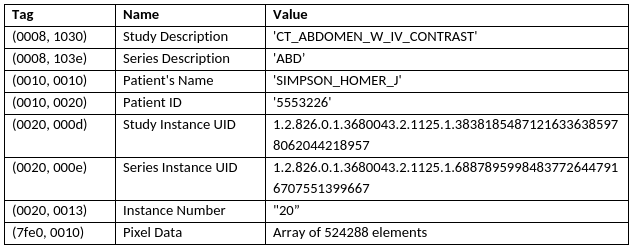


Poglobitev v dataset: `series`, `slices`, and `uid`. 

1. **Name: series**  
    - **Type: collections.defaultdict**  
    - **Value: <defaultdict, len() = 836>**  
      - This is a Python `defaultdict` (from the `collections` module), which is a dictionary that automatically creates default values for missing keys (e.g., if you access a key that doesn't exist, it might return an empty list or dict by default).  
      - It contains 836 items (likely key-value pairs). Without seeing the actual contents, I can't say for sure what the keys/values are, but in a DICOM context (common for medical imaging), this could represent a collection of "series" (e.g., groups of related images from a scan, like MRI slices or CT scans). Each entry might correspond to a DICOM Series Instance UID or metadata about a series.  
      - If this is from a script processing DICOM files (e.g., using libraries like `pydicom`), the defaultdict might be used to group data by series for efficiency.

2. **Name: slices**  
    - **Type: list**  
    - **Value: []**  
      - This is an empty Python list. In a DICOM or imaging context, "slices" often refer to individual 2D images from a 3D volume (e.g., cross-sections of a brain scan). The list being empty suggests it hasn't been populated yet—perhaps it's meant to hold processed image data, file paths, or pixel arrays from the `series` data.

3. **Name: uid**  
    - **Type: str**  
    - **Value: '1.3.12.2.1107.5.8.15.132326.30000025090514455763900069706'**  
      - This is a string representing a unique identifier (UID). The format matches DICOM (Digital Imaging and Communications in Medicine) standards, which are used globally for medical imaging data. Specifically:  
         - It looks like a **Study Instance UID** (a unique ID for an entire imaging study, like a patient's MRI session). DICOM UIDs are hierarchical and globally unique, often assigned by devices like scanners.  
         - The prefix `1.3.12.2.1107.5.8.15` is a standard root (possibly from a vendor like Siemens or Philips), followed by a timestamp-like suffix.  
      - If this is from a DICOM file or dataset, it could be used to link the `series` and `slices` data back to the original study.


- **Why a defaultdict for series?** It's efficient for grouping data without worrying about missing keys. For instance, if you're iterating through DICOM files, you could do something like:
  ```python
  series = defaultdict(list)  # Or whatever default you need
  # Then populate it with series data
  ```
- **Empty slices list**: This might indicate the script is in an early stage (e.g., before loading image data) or that no slices have been extracted yet.

primer: 
  ```python
  # Assuming 'series' is your defaultdict
  print(f"Number of series: {len(series)}")
  for key, value in series.items():
        print(f"Series {key}: {len(value)} items")  # Adjust based on what 'value' is

Razumevanje knjižnice PYDICOM 

useful link: https://pydicom.github.io/pydicom/dev/guides/cli/cli_guide.html

Uporabne komande:
    
```python
    # Read one file from the dataseries; stop_before_pixels -> doesnt show the graphical data (image)
    ds = pydicom.dcmread(files[0], stop_before_pixels=True, force=True) 

<hr style="border: 1px solid white; margin-top: 1px;">

*25.02.2026*  
<hr style="border: 1px solid white; margin-top: 1px;">

Boljše razumevanje funkcije nalaganja podatkov in zbiranja v series.

```python 
series[str(uid)].append(f)
```
means:

* Key → ``str(uid)`` (series identifier as a string)

* Value → a list of files belonging to that key

* ``f`` → one file path that gets appended to that list

Na osnovi ```uid``` - unique identifier - se posamezne podatke iz seta zbirajo v serijo.

Analogija:

 * Series UID = folder name
 * Files = items inside that folder

Lista vseh atributov, za lažje razumevanje:

```python
series = find_dicom_series(r"/data0/markok/data_pet/PET_CT_brain_UKC_Nevro/Gasper_prvi_paket/")
# List of all attributes
for uid, files in series.items():
        # Read one file to get series metadata (series are similar, processing time is longer for all)
        ds = pydicom.dcmread(files[0], stop_before_pixels=True, force=True)
        for elem in ds:
                print(elem) 
```

Atributi se ponavljajo, zato je bilo bolj smiselno, da se najprej naredi grupiranje po pacientov, nato pa prikaz liste od enega pacienta:

```python
patient_key = list(patients.keys())[0]
studies = patients[patient_key]
study_uid = list(studies.keys())[0]
series_uids = studies[study_uid]
series_uid = series_uids[0]
file_path = series[series_uid][0]
ds = pydicom.dcmread(file_path, stop_before_pixels=True, force=True)
for elem in ds:
    print(elem)

Lista atributov:



```
(0008,0005) Specific Character Set              CS: 'ISO_IR 192'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL', 'CT_SOM5 SPI']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000072
(0008,0020) Study Date                          DA: '20250220'
(0008,0021) Series Date                         DA: '20250220'
(0008,0022) Acquisition Date                    DA: '20250220'
(0008,0023) Content Date                        DA: '20250220'
(0008,002A) Acquisition DateTime                DT: '20250220144618.626000'
(0008,0030) Study Time                          TM: '143953.971000'
(0008,0031) Series Time                         TM: '144627.853000'
(0008,0032) Acquisition Time                    TM: '144618.626000'
(0008,0033) Content Time                        TM: '144618.626000'
(0008,0050) Accession Number                    SH: 'F01ACT672501048'
(0008,0060) Modality                            CS: 'CT'
(0008,0070) Manufacturer                        LO: 'SIEMENS'
(0008,0090) Referring Physician's Name          PN: ''
(0008,1030) Study Description                   LO: 'PET^03_18F_FDG_Brain (Adult)'
(0008,1032) Procedure Code Sequence             SQ: <Sequence, length 1>
(0008,103E) Series Description                  LO: 'AC   CT Brain  3.0  Hf38'
(0008,1090) Manufacturer's Model Name           LO: 'Biograph128_mCT 4R Edge'
(0008,1110) Referenced Study Sequence           SQ: <Sequence, length 1>
(0008,1120) Referenced Patient Sequence         SQ: <Sequence, length 1>
(0008,1140) Referenced Image Sequence           SQ: <Sequence, length 1>
(0008,2111) Derivation Description              ST: "Forced 'Reduced' Anonymity - Service"
(0008,2112) Source Image Sequence               SQ: <Sequence, length 1>
(0008,3010) Irradiation Event UID               UI: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000008
(0009,0010) Private Creator                     LO: 'SIEMENS CT VA1 DUMMY'
(0010,0010) Patient's Name                      PN: ''
(0010,0020) Patient ID                          LO: ''
(0010,0021) Issuer of Patient ID                LO: 'HIS01'
(0010,0030) Patient's Birth Date                DA: '20250801'
(0010,0040) Patient's Sex                       CS: 'M'
(0010,1010) Patient's Age                       AS: '080Y'
(0010,1020) Patient's Size                      DS: '1.75'
(0010,1030) Patient's Weight                    DS: '72'
(0012,0062) Patient Identity Removed            CS: 'YES'
(0012,0063) De-identification Method            LO: 'Service Use'
(0018,0015) Body Part Examined                  CS: 'HEAD'
(0018,0050) Slice Thickness                     DS: '3'
(0018,0060) KVP                                 DS: '100'
(0018,0090) Data Collection Diameter            DS: '500'
(0018,1000) Device Serial Number                LO: '60019'
(0018,1020) Software Versions                   LO: 'VG80B'
(0018,1030) Protocol Name                       LO: '03_18F_FDG_Brain'
(0018,1100) Reconstruction Diameter             DS: '500'
(0018,1110) Distance Source to Detector         DS: '1085.6'
(0018,1111) Distance Source to Patient          DS: '595'
(0018,1120) Gantry/Detector Tilt                DS: '0'
(0018,1130) Table Height                        DS: '204'
(0018,1140) Rotation Direction                  CS: 'CW'
(0018,1150) Exposure Time                       IS: '1000'
(0018,1151) X-Ray Tube Current                  IS: '85'
(0018,1152) Exposure                            IS: '154'
(0018,1160) Filter Type                         SH: 'FLAT'
(0018,1170) Generator Power                     IS: '6'
(0018,1190) Focal Spot(s)                       DS: '0.9'
(0018,1200) Date of Last Calibration            DA: '20250220'
(0018,1201) Time of Last Calibration            TM: '070933.000000'
(0018,1210) Convolution Kernel                  SH: 'Hf38s'
(0018,5100) Patient Position                    CS: 'HFS'
(0018,9306) Single Collimation Width            FD: 0.6
(0018,9307) Total Collimation Width             FD: 38.4
(0018,9309) Table Speed                         FD: 21.1
(0018,9310) Table Feed per Rotation             FD: 21.1
(0018,9311) Spiral Pitch Factor                 FD: 0.55
(0018,9313) Data Collection Center (Patient)    FD: [0.0, -204.0, -148.5]
(0018,9318) Reconstruction Target Center (Patie FD: [0.0, -204.0, -148.5]
(0018,9323) Exposure Modulation Type            CS: 'Z_EC'
(0018,9324) Estimated Dose Saving               FD: 24.114
(0018,9345) CTDIvol                             FD: 13.47679302369668
(0018,9346) CTDI Phantom Type Code Sequence     SQ: <Sequence, length 1>
(0018,9352) Calcium Scoring Mass Factor Device  FL: [0.6790000200271606, 0.7139999866485596, 0.7459999918937683]
(0019,0010) Private Creator                     LO: 'SIEMENS CT VA0  COAD'
(0019,1090) [Osteo Offset]                      DS: '0'
(0019,1092) [Osteo Regression Line Slope]       DS: '0.9236'
(0019,1093) [Osteo Regression Line Intercept]   DS: '-1.6565'
(0019,1096) [Osteo Phantom Number]              IS: '0'
(0019,10B0) [Feed per Rotation]                 DS: '21.1'
(0020,000D) Study Instance UID                  UI: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000006
(0020,000E) Series Instance UID                 UI: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000009
(0020,0010) Study ID                            SH: 'F01ACT672501048'
(0020,0011) Series Number                       IS: '2'
(0020,0012) Acquisition Number                  IS: '2'
(0020,0013) Instance Number                     IS: '62'
(0020,0032) Image Position (Patient)            DS: [-249.51171875, -453.51171875, -148.5]
(0020,0037) Image Orientation (Patient)         DS: [1, 0, 0, 0, 1, 0]
(0020,0052) Frame of Reference UID              UI: 1.3.12.2.1107.5.8.15.133122.30000025080112534686100000010
(0020,1040) Position Reference Indicator        LO: ''
(0020,1041) Slice Location                      DS: '-148.5'
(0020,4000) Image Comments                      LT: ''
(0021,0010) Private Creator                     LO: 'SIEMENS MED'
(0021,1011) [Target]                            DS: [0, 0]
(0028,0002) Samples per Pixel                   US: 1
(0028,0004) Photometric Interpretation          CS: 'MONOCHROME2'
(0028,0010) Rows                                US: 512
(0028,0011) Columns                             US: 512
(0028,0030) Pixel Spacing                       DS: [0.9765625, 0.9765625]
(0028,0100) Bits Allocated                      US: 16
(0028,0101) Bits Stored                         US: 12
(0028,0102) High Bit                            US: 11
(0028,0103) Pixel Representation                US: 0
(0028,0106) Smallest Image Pixel Value          US: 0
(0028,0107) Largest Image Pixel Value           US: 3096
(0028,1050) Window Center                       DS: [35, 700]
(0028,1051) Window Width                        DS: [80, 3200]
(0028,1052) Rescale Intercept                   DS: '-1024'
(0028,1053) Rescale Slope                       DS: '1'
(0028,1054) Rescale Type                        LO: 'HU'
(0028,1055) Window Center & Width Explanation   LO: ['WINDOW1', 'WINDOW2']
(0029,0010) Private Creator                     LO: 'SIEMENS MEDCOM HEADER'
(0029,0011) Private Creator                     LO: 'SIEMENS CSA HEADER'
(0029,1040) [Application Header Sequence]       SQ: <Sequence, length 2>
(0029,1108) [CSA Image Header Type]             CS: 'SOM 5'
(0029,1109) [CSA Image Header Version]          LO: 'VA10A 971201'
(0029,1110) [CSA Image Header Info]             OB: Array of 1400 elements
(0032,1032) Requesting Physician                PN: 'Vudrag^Borna'
(0032,1060) Requested Procedure Description     LO: 'PET FDG možgan'
(0032,1064) Requested Procedure Code Sequence   SQ: <Sequence, length 1>
(0040,0275) Request Attributes Sequence         SQ: <Sequence, length 1>

Razumevanje podatkov: DONE 
next step - vizualizija - razumevanje grafičnih podatkov DICOM

Pomemben atribut - image position: 

```(0020,0032) Image Position (Patient)                    ----     DS: [-249.51171875, -453.51171875, -148.5]```

[x,y,z] koordinate v milimetrih

<hr style="border: 1px solid white; margin-top: 1px;">

*26.02.2026*  
<hr style="border: 1px solid white; margin-top: 1px;">

<h4> Vizualizacija podatkov </h4>

ZAKLJUČEK: 
* CT dimenzije - 512x512
* PET dimenzije - 400x400

Ideja: Stack prerezov vzdolž Z osi:

```python
def sort_instances(files):
    """Sort DICOM instance files into slice order. Returns list of pydicom datasets."""
    dsets = []
    for f in files:
        try:
            ds = pydicom.dcmread(f, force=True)
            dsets.append(ds)
        except Exception:
            continue

    def z_key(ds):
        ipp = getattr(ds, "ImagePositionPatient", None)  
        if ipp is not None and len(ipp) == 3:
            return float(ipp[2])
        return float(getattr(ds, "InstanceNumber", 0))

    dsets.sort(key=z_key)
    return dsets

def load_volume_from_series(files, apply_rescale=True):
    """Load a DICOM series into a 3D numpy array (Z, Y, X)."""
    dsets = sort_instances(files) # get sorted pydicom datasets for this series on the axis of acquisition (Z) 
    if not dsets:
        raise ValueError("No readable DICOM instances in this series.")

    vol = []
    for ds in dsets:
        arr = ds.pixel_array.astype(np.float32)

        if apply_rescale:
            slope = float(getattr(ds, "RescaleSlope", 1.0))
            inter = float(getattr(ds, "RescaleIntercept", 0.0))
            arr = arr * slope + inter

        vol.append(arr)

    vol = np.stack(vol, axis=0)  # (Z, Y, X) classical
    return vol, dsets[0]         # return first ds for metadata
    ```

TODO: Napiši kodo za check spacing in orientacijo. Dodatno še preberi o spacing in orientation v DICOM literaturo